In [1]:
from netCDF4 import Dataset
import datetime
import matplotlib
import pandas as pd
import os
import numpy as np
from scipy.signal import argrelextrema
import pickle
import warnings
import matplotlib.pyplot as plt
from ll_xy import lonlat_to_xy
import kuka_tools as kt
# You can find kuka_tools at https://github.com/robbiemallett/custom_modules/blob/master/kuka_tools.py

Text(0, 0.5, 'y distance (m)')

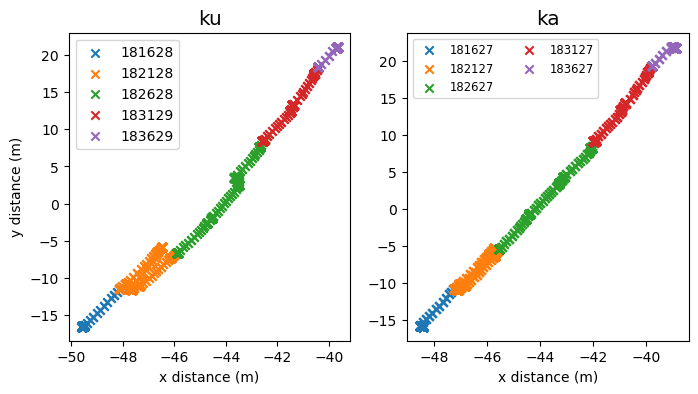

In [2]:
# directory='/media/robbie/Elements/KUKA/KUKA_PROCESSED/20230923'
directory='/home/robbie/Dropbox/kuka_slush/data/kuka/20230923'
freqs=['ku','ka']
listfiles = os.listdir(directory)
files = {'ku':sorted([f for f in listfiles if f'Ku-Scat' in f]),
         'ka':sorted([f for f in listfiles if f'Ka-Scat' in f])}

files['ku'] =  [f for f in files['ku'] if "-14" not in f]
files['ka'] =  [f for f in files['ka'] if "-14" not in f]
files['ka'] =  [f for f in files['ka'] if "-180" not in f]
files['ka'] =  [f for f in files['ka'] if "1814" not in f]

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(8,4))

xy_dict = {}

for freq, ax in zip(freqs,[ax1,ax2]):
    
    ax.set_title(freq,fontsize='x-large')
    
    x,y=kt.plot_pos(files['ku'][0],directory,plot=False)

    x0 = -2300414.994491106; y0 = 923485.871699531

    xy_dict[freq]={}
    
    for f in files[freq]:

        x,y = kt.plot_pos(f,directory,x0=x0,y0=y0,ax=ax)

        xy_dict[freq][f] = (x,y)

ax1.legend()
ax2.legend(ncol=2,fontsize='small')
ax1.set_xlabel('x distance (m)')
ax2.set_xlabel('x distance (m)')
ax1.set_ylabel('y distance (m)')

In [3]:
# for freq in freqs:
    
#     for f in files[freq]:
#         kt.plot_file(f,freq.lower(),directory,
#                          vlines=[])

In [4]:
nearfardict = {}

for freq in ['ku','ka']:
    
    file = files[freq][0]
    d = Dataset(f'{directory}/{file}')
    near=kt.get_range_index(1.3,d['range'])
    far=kt.get_range_index(2,d['range'])
    nearfardict[freq] = {'near':near,'far':far,'range':np.array(d['range'])[near:far]}

/tmp/ipykernel_3968/3608431213.py:9: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  nearfardict[freq] = {'near':near,'far':far,'range':np.array(d['range'])[near:far]}


# Join files

In [5]:
with warnings.catch_warnings():
    
    warnings.simplefilter('ignore')
        
    
    data = {}
    
    for freq in ['ku','ka']:
    
        nrcs_list = []
        for foi in files[freq][:]:
    
            x,y=xy_dict[freq][foi]
    
            d = Dataset(f'{directory}/{foi}')
    
            time_offset_s=0
            times = np.array([datetime.datetime(1970,1,1)+datetime.timedelta(seconds=int(x))+datetime.timedelta(seconds=int(time_offset_s)) for x in d['start_time']])
    
            mintime=0
            maxtime=100000
    
            nrcs = pd.DataFrame(kt.get_nrcs(d,freq.lower()))
    
            x_ = 0; y_ = 0
    
            along_track = np.sqrt((x-x_)**2 + (y-y_)**2)
            xdiff = np.diff(x)
            ydiff = np.diff(y)
            speed = np.sqrt(np.square(xdiff)+np.square(ydiff))
            speed=list(speed)+[0]
            nrcs['speed']=speed
            nrcs['time']=np.array(d['start_time'])
            nrcs['x']=x
            nrcs['y']=y
            nrcs['xtilt']=np.array(d['cross_tilt'])
            nrcs['atilt']=np.array(d['along_tilt'])
            nrcs = nrcs.iloc[mintime:maxtime]
    
            vv= np.array(d['vv_power_decon0'])[nearfardict[freq]['near']:nearfardict[freq]['far'],
                                               mintime:maxtime]
            
            hv= np.array(d['hv_power_decon0'])[nearfardict[freq]['near']:nearfardict[freq]['far'],
                                   mintime:maxtime]

            nrcs['vv'] = [vv[:,i] for i in range(vv.shape[1])]
            nrcs['hv'] = [hv[:,i] for i in range(hv.shape[1])]
    
            nrcs = nrcs[nrcs['corr']<0.99]
    
            # nrcs_list.append( nrcs.sort_values('along_track').reset_index() )
            nrcs_list.append( nrcs )
            
    
        data[freq] = pd.concat(nrcs_list)

# Select freqency here!

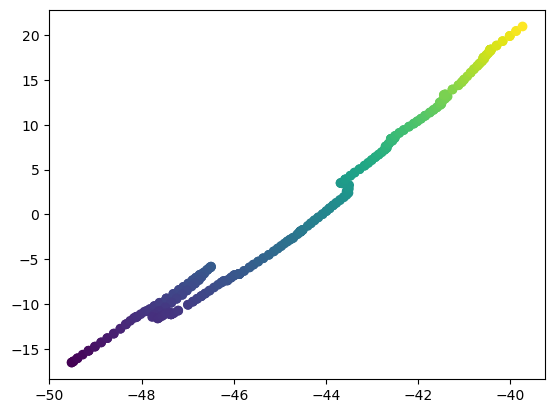

In [6]:
freq = 'ku'

df = data[freq]

x0=np.min(df['x'])
y0=np.min(df['y'])
df['along_track']=np.sqrt((df['x']-x0)**2+(df['y']-y0)**2)


plt.scatter(df['x'],df['y'],c=df['along_track'])

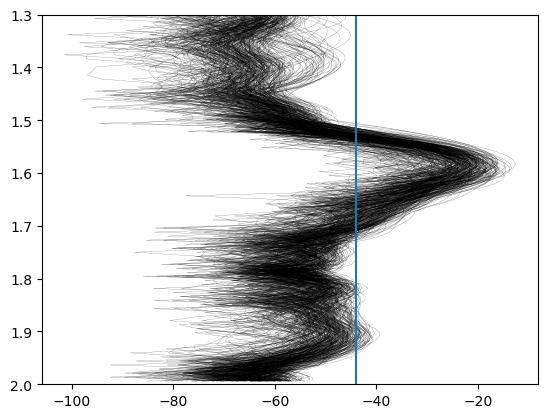

In [7]:
ranges=nearfardict[freq]['range']

alpha=0.5 if freq=='ka' else 1

for i in range(df.shape[0]):
    d = df.iloc[i]
    power=d['vv']

    plt.plot(10*np.log10(power),
         ranges,
             alpha=alpha,
         color='k',lw=0.1)


plt.ylim(2,1.3)
# plt.xlim(-10,0)
if freq=='ka':
    plt.axvline(-50)
else:
    plt.axvline(-44)
plt.show()

# Analyse peaks

In [8]:
thresh = -44 if freq=='ku' else -50

npeaks = []

multi_peak_inds = {x:{} for x in range(1,5)}

shifts=[]

multipeaks=[]

for i in range(df.shape[0]):
    
    power_vv = df['vv'].iloc[i]
    power_hv = df['hv'].iloc[i]
    
    # Identify all peaks more than 10% of max power
    
    ### Identify the indexes of all local maxima
    
    max_inds = argrelextrema(power_vv, np.greater)[0]
    
    ### Catalogue the characteristics of the local maxima
    
    list_of_dicts_for_df = [{'ind':q,'power_vv':power_vv[q],'power_hv':power_hv[q],
                             'range':nearfardict[freq]['range'][q]} for q in max_inds]
    
    ### Sort dataframe so modst powerful peaks at top
    
    peaks_df = pd.DataFrame(list_of_dicts_for_df).sort_values('power_vv',ascending=False)
    
    max_power = peaks_df.iloc[0]['power_vv']

    # Filter out weak peaks with a threshold to remove sidelobes
    peaks_df = peaks_df[10*np.log10(peaks_df['power_vv'])>thresh]
    
    if peaks_df.shape[0]>0:
        
        # Sort peaks into ascending range
        peaks_df = peaks_df.sort_values('range',ascending=True)
    
        # Append the index of the first significant peak to calculate waveform shifts
        shifts.append(peaks_df.iloc[0]['ind'])

    else:
        shifts.append(np.nan)
        
    # Log npeaks to main dataframe
    npeaks.append(peaks_df.shape[0])

    multipeaks.append(peaks_df)
    
    for pn in range(1,5):
        if peaks_df.shape[0] == pn:
            multi_peak_inds[pn][i] = peaks_df
            
df['shifts']=shifts
df['range_shift']=[ranges[int(x)] if ~np.isnan(x) else np.nan for x in df['shifts'] ]
df['npeaks']=npeaks

pickle.dump(df,open(f'23_{freq}.p','wb'))

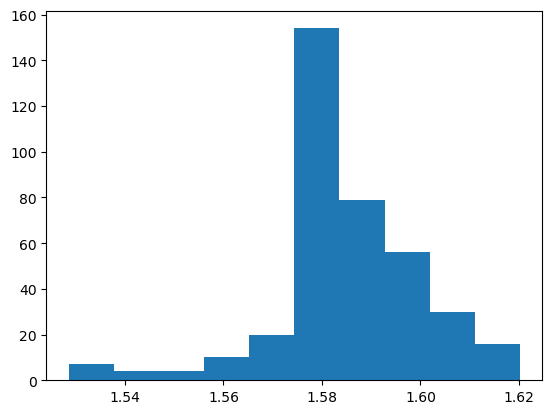

-0.0027505975020556406 0.015166191899803063


In [9]:
plt.hist(df['range_shift'])
plt.show()
q=df['range_shift']-np.nanmean(df['range_shift'])
print(np.nanmedian(q),np.nanstd(q))

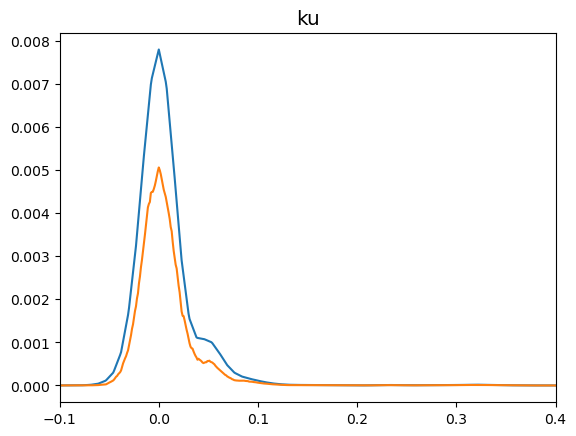

In [10]:
xinterp = np.arange(-0.1,0.50,0.001)
     

yints=[]
peak_dfs = []
for i in range(df.shape[0]):

    yinterp_vv = np.interp(xinterp,ranges-df['range_shift'].iloc[i],
             df['vv'].iloc[i])
    
    yinterp_hv = np.interp(xinterp,ranges-df['range_shift'].iloc[i],
         df['hv'].iloc[i])


    ### Identify the indexes of all local maxima
    
    max_inds = argrelextrema(yinterp_vv, np.greater)[0]
    
    ### Catalogue the characteristics of the local maxima
    
    list_of_dicts_for_df = [{'ind':q,
                             'vv_power':yinterp_vv[q],
                             'hv_power':yinterp_hv[q],
                             'range':xinterp[q]} for q in max_inds]
    
    ### Sort dataframe so modst powerful peaks at top
    
    peaks_df = pd.DataFrame(list_of_dicts_for_df).sort_values('vv_power',
                                                              ascending=False)
    
    max_power = peaks_df.iloc[0]['vv_power']
    
    # Calculate power of each peak relative to max power
    # peaks_df['rel_power'] = [x/max_power for x in peaks_df['power']]
    
    # Filter out weak peaks with a threshold to remove sidelobes
    peaks_df = peaks_df[10*np.log10(peaks_df['vv_power'])>thresh]
    
    # Sort peaks into ascending range
    peaks_df = peaks_df.sort_values('range',ascending=True)

    peaks_df=peaks_df[peaks_df['range']<0.15]

    # peaks_df = peaks_df[peaks_df['range']<0.12]

    peak_dfs.append(peaks_df)

    if peaks_df.shape[0]>1:

        yints.append(yinterp_vv)


ymean = np.nanmean(yints,axis=0)
plt.plot(xinterp,ymean)


ymedian = np.nanmedian(yints,axis=0)
plt.plot(xinterp,ymedian)
# plt.ylim(0,0.0002)

plt.title(freq,fontsize='x-large')
plt.xlim(-0.1,0.4)
plt.show()

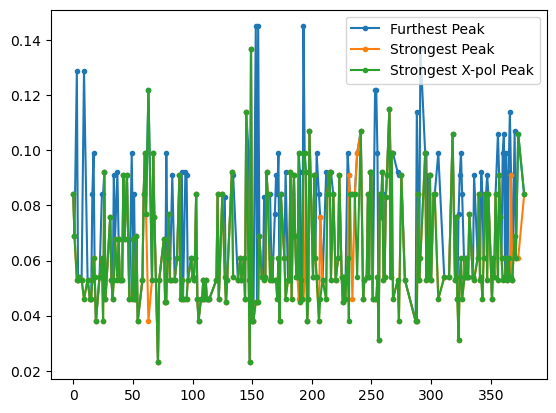

In [12]:
counts_valid=[]

r_rmaxs_valid=[]
p_rmaxs=[]

r_xmaxs_valid=[]
p_xmaxs=[]

r_amaxs_valid=[]
p_amaxs=[]

r_nearests=[]
p_nearests=[]

magna=[]

p0=[]

for count,peak_df in enumerate(peak_dfs):

    if peak_df.shape[0]>1:

        # Calculate index of maximum power below the snow
        amax=np.argmax(peak_df.iloc[1:]['vv_power'])
        # Calculate range of peak with max power
        r_amax = peak_df.iloc[1:].iloc[amax]['range']
        # Calculate power of peak with max power
        a_amax = peak_df.iloc[1:].iloc[amax]['vv_power']        
        # Calculate range of furthest peak in range
        r_rmax = peak_df.iloc[-1]['range']
        a_rmax = peak_df.iloc[-1]['vv_power']

        # Calculate index of strongest x-pol power below the snow
        xmax=np.argmax(peak_df.iloc[1:]['hv_power'])
        # Calculate range of peak with max power
        r_xmax = peak_df.iloc[1:].iloc[xmax]['range']
        a_xmax = peak_df.iloc[1:].iloc[xmax]['vv_power']

        counts_valid.append(count)
        r_rmaxs_valid.append(r_rmax)
        r_amaxs_valid.append(r_amax)
        r_xmaxs_valid.append(r_xmax)
        # r_nearests.append(r_nearest)

        p_rmaxs.append(a_rmax)
        p_amaxs.append(a_amax)
        p_xmaxs.append(a_xmax)
        p0.append(peak_df.iloc[0]['vv_power'])
        # p_nearests.append(p_nearest)
    
        
        # magna.append(1.25*magna_depth)
        
plt.plot(counts_valid,r_rmaxs_valid,label='Furthest Peak',marker='.')
plt.plot(counts_valid,r_amaxs_valid,label='Strongest Peak',marker='.')
plt.plot(counts_valid,r_xmaxs_valid,label='Strongest X-pol Peak',marker='.')
# plt.plot(counts_valid,r_nearests,label='Nearest to Magna',marker='.')
# plt.plot(counts_valid,magna,label='Magna',marker='.')
plt.legend()

In [13]:
from scipy.stats import linregress

In [14]:
print(np.nanmean(p_xmaxs))
print(np.nanmean(p_rmaxs))
print(np.nanmean(p_amaxs))
print(np.nanmean(p_nearests))

0.0009824173842229158
0.000658302250374728
0.0010698599647933694
nan


/tmp/ipykernel_19462/2515907514.py:4: RuntimeWarning: Mean of empty slice
  print(np.nanmean(p_nearests))


In [17]:
print(np.nanmedian(p_xmaxs))
print(np.nanmedian(p_rmaxs))
print(np.nanmedian(p_amaxs))
# print(np.nanmedian(p_nearests))

0.00035927823619134967
0.00015669267954158226
0.00039342147385364233


In [14]:
products=['xmax','rmax','pmax','p0']
ps=[p_xmaxs,p_rmaxs,p_amaxs,p0]


powers={q:m for q,m in zip(products,ps)}
pickle.dump(powers,open('/home/robbie/Dropbox/kuka_slush/code/ice_powers/roth0_power.p','wb'))



In [18]:
products=['xmax','rmax','pmax']
for i,p in zip([r_xmaxs_valid,
          r_rmaxs_valid,
          r_amaxs_valid],
               products):

    r=linregress(magna,i)[2]
    
    print(p,r)

ValueError: Inputs must not be empty.

(380, 16)
(53,)
(380, 53)


/tmp/ipykernel_166061/2961589085.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


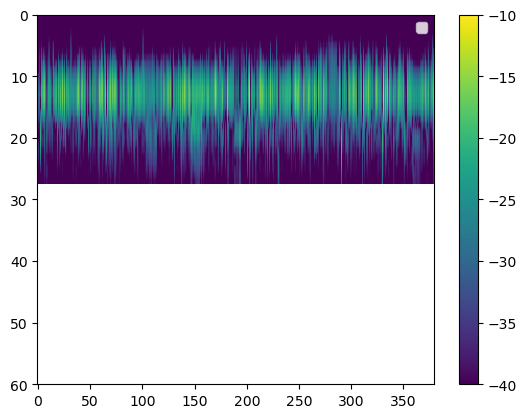

In [73]:
if freq=='ku':
    n=53
elif freq=='ka':
    n=120

print(df.shape)

# echogram=np.full((df.shape[0],n),np.nan)
echogram_vv=[];echogram_hv=[]
at_valid=[]
for i in range(df.shape[0]):
    d = df.iloc[i]
    power_vv=d['vv']
    power_hv=d['hv']
    
    shift=d['shifts']

    if np.isnan(shift):
        echogram.append([np.nan]*n)

    else:
        
        shift=int(shift)
        
        shifted_ranges = ranges-ranges[shift]
        
        power_in_range_vv = power_vv[(shifted_ranges>-0.1)&(shifted_ranges<0.3)]
        power_in_range_hv = power_hv[(shifted_ranges>-0.1)&(shifted_ranges<0.3)]
        
        if i==0:
            print(power_in_range_vv.shape)
            
        if power_in_range_vv.shape[0]==n:
            
            echogram_vv.append(10*np.log10(power_in_range_vv))
            echogram_hv.append(10*np.log10(power_in_range_hv))

echogram_vv=np.array(echogram_vv)
echogram_hv=np.array(echogram_hv)



print(echogram_vv.shape)
e2=echogram_vv.T.copy()
# e2[e2<thresh]=np.nan
plt.imshow(e2[:28,:],vmin=-40,vmax=-10,aspect='auto')

# e2=echogram_vv.T.copy()
# hv_thresh=-65
# e2[e2<hv_thresh]=np.nan
# plt.imshow(e2,vmin=-60,vmax=-10)


plt.legend()
plt.ylim(60,0)
plt.colorbar()

Shift stats for Ku:

 -0.0038548519736838482 0.014073294310865713
 
Shift stats for Ka:

-0.0006242231889204142 0.014744097345810798

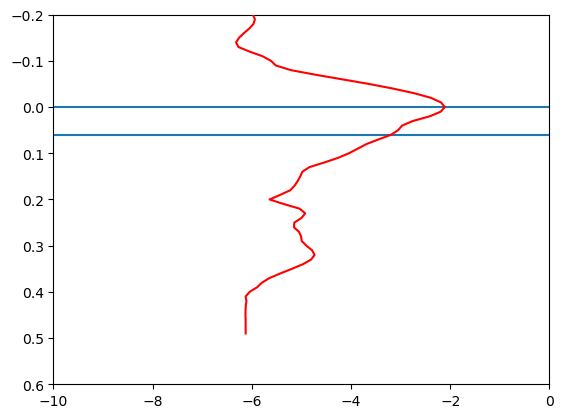

In [11]:
xinterp=np.arange(-0.2,0.5,0.01)

y1=[]
for i in range(df.shape[0]):
    d = df.iloc[i]
    power=d['vv']
    range_shift=d['range_shift']
    
    yinterp=np.interp(xinterp,ranges-range_shift,power)
    y1.append(yinterp)

    plt.plot(10*np.log10(power),
         ranges-range_shift,
         color='k',lw=0.1)


y1m=np.nanmean(y1,axis=0)
plt.plot(np.log10(y1m),xinterp,color='r',zorder=100)
    

plt.ylim(0.6,-0.2)
plt.xlim(-10,0)

plt.axhline(0)
plt.axhline(0.06)

plt.show()

In [12]:
n=66
echogram=np.full((df.shape[0],n),np.nan)
echogram=[]
at_valid=[]
for i,mp,fp in zip(range(df.shape[0]),multipeaks,first_powers):
    d = df.iloc[i]
    power=d['vv']
    power=d['vv']/fp
    along_track=d['along_track']
    shift=int(d['shifts'])
    
    # normed_power = np.log10(power/mp.iloc[0]['power'])
    normed_power=power
    shifted_ranges = ranges-ranges[shift]

    power_in_range = normed_power[(shifted_ranges>-0.1)&(shifted_ranges<0.4)]
    # print(power_in_range.shape)
    if power_in_range.shape[0]==n:
        # echogram[i,:]=power_in_range
        echogram.append(power_in_range)
        at_valid.append(along_track)

echogram=np.array(echogram)
at_valid=np.array(at_valid)

plt.figure(figsize=(8,8))
plt.imshow(echogram.T[:30],
           vmin=0.0,vmax=3,
           cmap='afmhot',aspect='auto',norm='linear')
plt.colorbar()
yaxis = shifted_ranges[(shifted_ranges>-0.1)&(shifted_ranges<0.4)]
yticks=np.arange(1,31,6)
ylabs=[np.round(yaxis[x],decimals=2) for x in yticks]
plt.yticks(yticks,labels=ylabs)
plt.show()

NameError: name 'first_powers' is not defined

In [13]:
at_linear=np.arange(0,33.6,0.01)

resampled_echogram=np.empty((at_linear.shape[0],n))

for counter,i in enumerate(at_linear):
    distance_to_ats = np.abs(at_valid-i)
    argmin = np.argmin(distance_to_ats)
    resampled_echogram[counter,:]=echogram[argmin]
    # break

plt.figure(figsize=(10,5))


plt.imshow(resampled_echogram.T[:30],
           vmin=0.000,vmax=1,
           cmap='afmhot',aspect='auto',norm='linear')

yaxis = shifted_ranges[(shifted_ranges>-0.1)&(shifted_ranges<0.4)]
print(yaxis.shape)
yticks=np.arange(1,31,6)
ylabs=[np.round(yaxis[x],decimals=2) for x in yticks]
plt.yticks(yticks,labels=ylabs)

xticks=np.arange(0,3360,95)
print(len(xticks))
labels=[int(at_linear[x]) for x in xticks]
plt.xticks(xticks,labels=np.arange(0,36),rotation=0)

plt.ylabel('Radar Range from Snow Surface (m)',fontsize='x-large')
plt.xlabel('Distance Along Transect (m)',fontsize='x-large')

plt.show()

ValueError: attempt to get argmin of an empty sequence

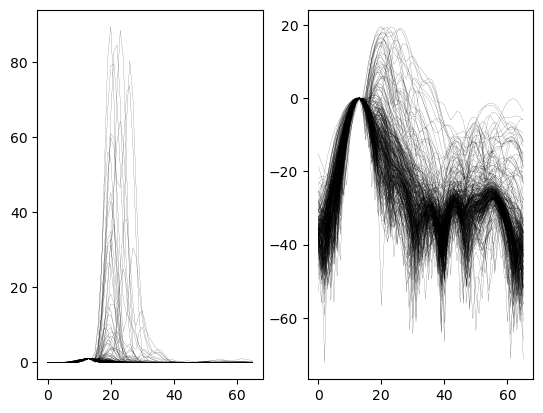

In [108]:
fig,(ax1,ax2)=plt.subplots(1,2)
for i in np.arange(0,326):
    e=echogram.T[:,i]
    ax1.plot(e,lw=0.1,c='k')
    ax2.plot(10*np.log10(e),lw=0.1,c='k')

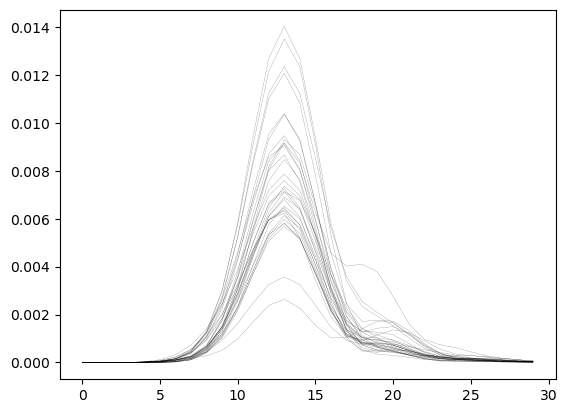

In [45]:
for i in range(0,330,10):
    a = np.average(echogr`am.T[:30,i:i+10],axis=1)
    plt.plot(a,lw=0.1,color='k')

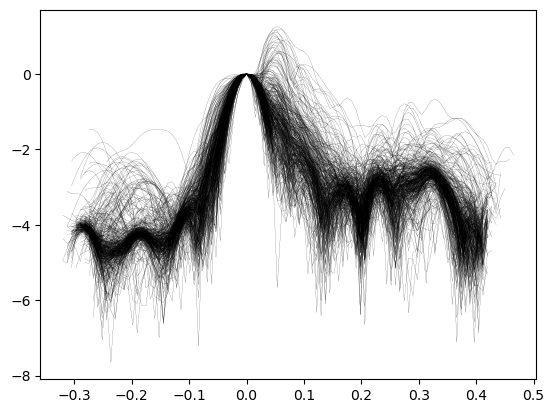

In [11]:
powers = []
shifts = []
peak1pow = []

ranges=nearfardict[freq]['range']

for pn in range(1,5):

    for i,peaks_df in multi_peak_inds[pn].items():

        power = df['vv'].iloc[i]
        
        powers.append(power)
        shifts.append(peaks_df.iloc[0]['ind'])
        peak1pow.append(peaks_df.iloc[0]['power'])
        
        plt.plot(ranges-peaks_df.iloc[0]['range'],
        # plt.plot(ranges,
                 np.log10(power/peaks_df.iloc[0]['power']),color='k',lw=0.1)
    
# plt.xlim(-0.1,0.4)

In [12]:
range_int=np.diff(nearfardict['ku']['range'])[0]
range_int

np.float64(0.00762939453125)

In [13]:
xaxis = np.arange(0,1000,range_int)[:60]-10*range_int

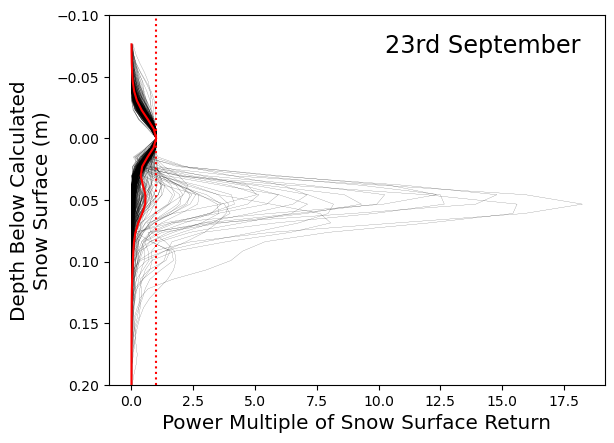

In [20]:
aligned_powers = []

for p,s,p1p in zip(powers,shifts,peak1pow):
    
    p_ = list([0]*(100-int(s)) + list(p)+[0]*100)[90:150]
    
    aligned_powers.append(p_/p1p)
    
    plt.plot(np.array(p_/p1p),xaxis,color='k',lw=0.1)
    
mean_pow = np.nanmean(aligned_powers,axis=0)

plt.plot(np.array(mean_pow),xaxis,color='r')
    
plt.ylim(0.2,-0.1)

plt.ylabel('Depth Below Calculated\nSnow Surface (m)',fontsize='x-large')

plt.xlabel('Power Multiple of Snow Surface Return',fontsize='x-large')

plt.axvline(1,color='r',ls=':')
# plt.ylim(-0.1,0.2)

plt.annotate('23rd September',xy=(0.95,0.95),ha='right',va='top',fontsize='xx-large',xycoords='axes fraction')

plt.savefig('23_September.png',dpi=500,bbox_inches='tight')

(-0.1, 0.2)

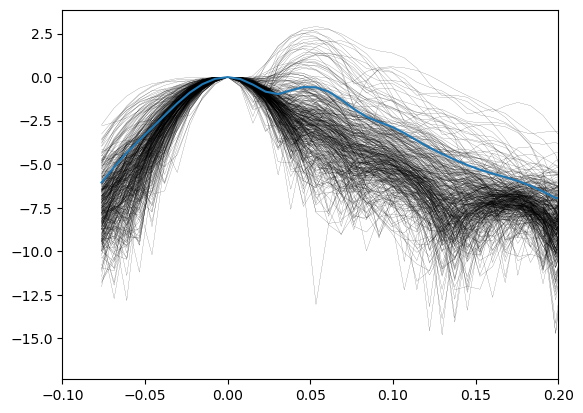

In [18]:
aligned_powers = []

for p,s,p1p in zip(powers,shifts,peak1pow):
    
    p_ = list([0]*(100-int(s)) + list(p)+[0]*100)[90:150]
    
    aligned_powers.append(p_/p1p)
    
    plt.plot(xaxis,np.log(p_/p1p),color='k',lw=0.1)
    
    
mean_pow = np.nanmean(aligned_powers,axis=0)

plt.plot(xaxis,np.log(mean_pow))
plt.xlim(-0.1,0.2)
    

In [16]:
np.nanmean(np.array(aligned_powers))

np.float64(0.14422286673365506)

In [17]:
peak_separations = []
peak_ratios = []
p2_power = []
p1_power = []

ranges=nearfardict[freq]['range']

for i,peaks_df in double_peak_indices.items():
    
    power = df['vv'].iloc[i]

    peak_separations.append( np.diff(peaks_df['range'])[0] )
    
    peak_ratios.append(peaks_df.iloc[0]['power']/peaks_df.iloc[1]['power'])
    
    p2_power.append(peaks_df.iloc[1]['power'])
    p1_power.append(peaks_df.iloc[0]['power'])
    
    plt.plot(ranges-peaks_df.iloc[0]['range'],
             power/peaks_df.iloc[0]['power'],color='k',lw=0.1)
    
    
    
peak_ratios = np.array(peak_ratios)

NameError: name 'double_peak_indices' is not defined

In [ ]:
peak_separations = []
peak_ratios = []
p2_power = []
p1_power = []

ranges=nearfardict[freq]['range']

for i,peaks_df in double_peak_indices.items():
    
    power = df['vv'].iloc[i]

    peak_separations.append( np.diff(peaks_df['range'])[0] )
    
    peak_ratios.append(peaks_df.iloc[0]['power']/peaks_df.iloc[1]['power'])
    
    p2_power.append(peaks_df.iloc[1]['power'])
    p1_power.append(peaks_df.iloc[0]['power'])
    
    plt.plot(ranges-peaks_df.iloc[0]['range'],
             power/peaks_df.iloc[0]['power'],color='k',lw=0.1)
    
    
    
peak_ratios = np.array(peak_ratios)

Text(0, 0.5, 'y distance (m)')

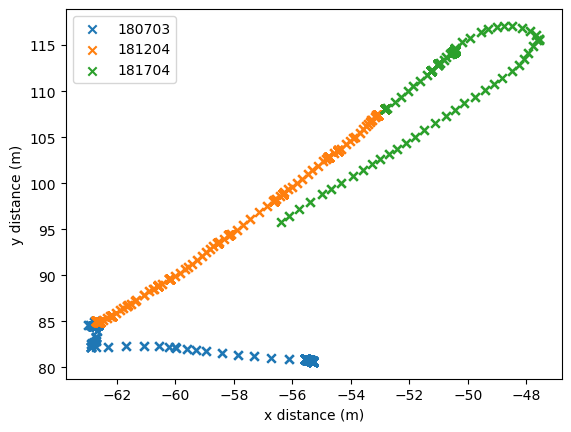

In [5]:
x0,y0 = 0,0

def plot_pos(file,plot=True,x0=0,y0=0):
    
    d = Dataset(f'{directory}/{file}')
    x, y = kt.lonlat_to_xy(np.array(d['lon']), np.array(d['lat']),hemisphere='s')
    y = y[np.abs(x)>10_000] -y0
    x = x[np.abs(x)>10_000] -x0
    if plot:
        plt.scatter(x,y,marker='x',label=file[-9:-3])

    return (x,y)

x,y=plot_pos('kuka_stare_decon_Ka-Scat20231002-135503.nc',plot=False)

x0 = x[0]; y0 = y[0]


# plot_pos('kuka_stare_decon_Ka-Scat20231002-180203.nc',x0=x0,y0=y0)
plot_pos('kuka_stare_decon_Ka-Scat20231002-180703.nc',x0=x0,y0=y0)
plot_pos('kuka_stare_decon_Ka-Scat20231002-181204.nc',x0=x0,y0=y0)
plot_pos('kuka_stare_decon_Ka-Scat20231002-181704.nc',x0=x0,y0=y0)

plt.legend()
plt.xlabel('x distance (m)')
plt.ylabel('y distance (m)')

# plt.xlim(-20,5)
# plt.ylim(-20,5)

In [6]:
pits = {}

In [7]:
# # Offset between Ka & ku
fa = 'kuka_stare_decon_Ka-Scat20231002-181204.nc'

fu = 'kuka_stare_decon_Ku-Scat20231002-181013.nc'

ka = Dataset(f'{directory}/{fa}')['start_time'][0]
ku = Dataset(f'{directory}/{fu}')['start_time'][0]
ka-ku

110.79099631309509

[]

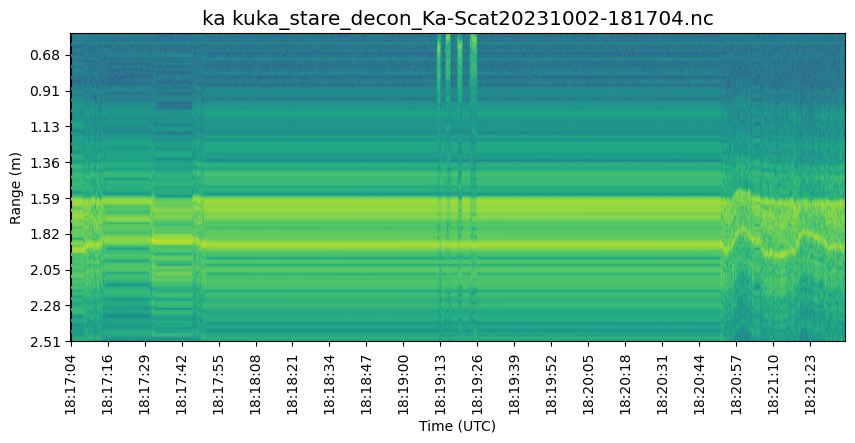

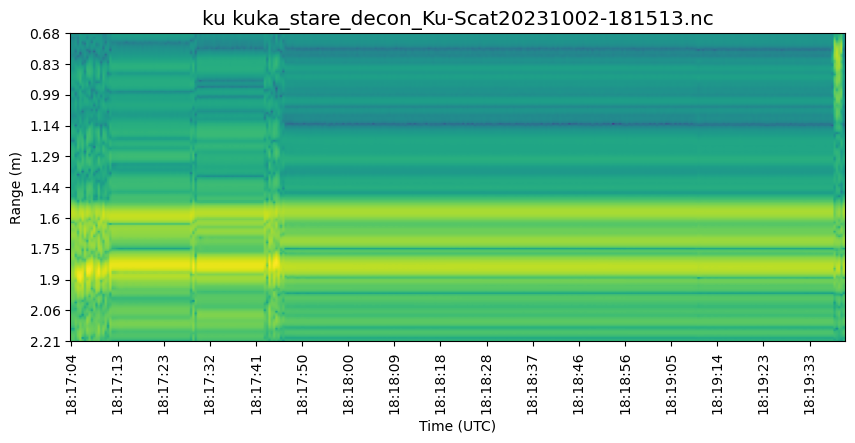

In [8]:
fa = 'kuka_stare_decon_Ka-Scat20231002-181704.nc'

fu = 'kuka_stare_decon_Ku-Scat20231002-181513.nc'

time_addition = datetime.timedelta(seconds=0)

ka_times = [(37,55)]
vlines = [datetime.datetime(2023,10,3,10,a,b)+time_addition for (a,b) in ka_times]
            # (30,30), (31,12)

kt.plot_file(fa,'ka',time_offset_s=0,vlines = vlines,directory=directory)

ku_times = []
vlines = [datetime.datetime(2023,10,2,11,a,b)+time_addition for (a,b) in ku_times]

kt.plot_file(fu,'ku',time_offset_s=-0+111,vlines=vlines,directory=directory)

datetime.timedelta(seconds=21109)

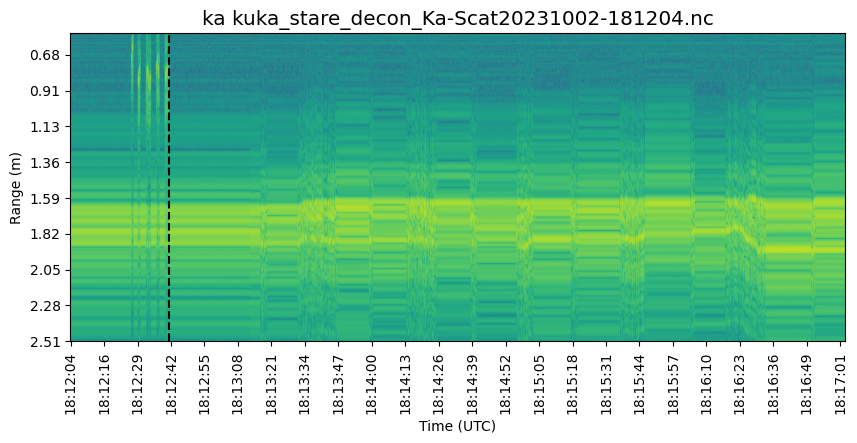

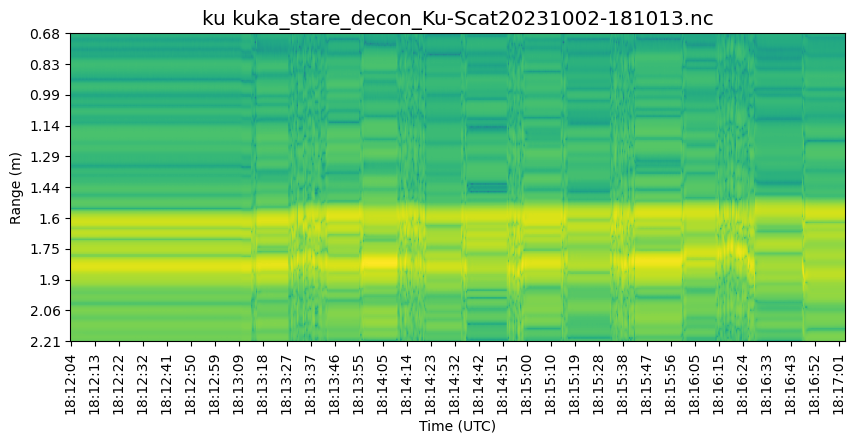

In [9]:
fa = 'kuka_stare_decon_Ka-Scat20231002-181204.nc'

fu = 'kuka_stare_decon_Ku-Scat20231002-181013.nc'

time_addition = datetime.timedelta(seconds=0)

ka_times = [(12,42)]
vlines = [datetime.datetime(2023,10,2,18,a,b)+time_addition for (a,b) in ka_times]

kt.plot_file(fa,'ka',time_offset_s=0,vlines = vlines,directory=directory)

ku_times = []
vlines = [datetime.datetime(2023,10,2,18,a,b)+time_addition for (a,b) in ku_times]

kt.plot_file(fu,'ku',time_offset_s=-0+111,vlines=vlines,directory=directory)

# Voice recording indicates that 18:12:42 kuka time is equal to 12:20:53 on phone

local_delta = datetime.datetime(2023,10,2,18,12,42)-datetime.datetime(2023,10,2,12,20,53)
local_delta

Loc 1
ka 12,21,07
ku 12,21,26

Loc 2
ka 12,21,55
ku 12,22,10

Loc 3
ka 12,22,32
ku 12,22,47

Loc 4
ka 12,23,10
ku 12,23,28

Loc 5
ka 12,23,54
ku 12,24,15

Loc 6
ka 12,24,51
ku 12,25,05

Loc 7
ka 12,25,25
ku 12,25,42

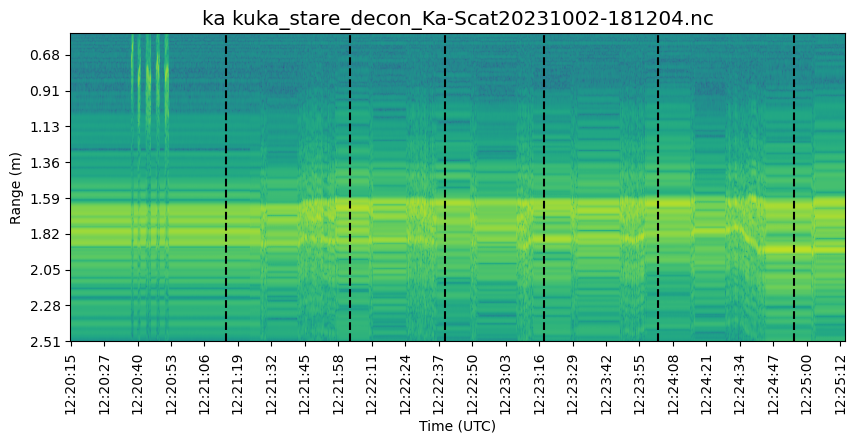

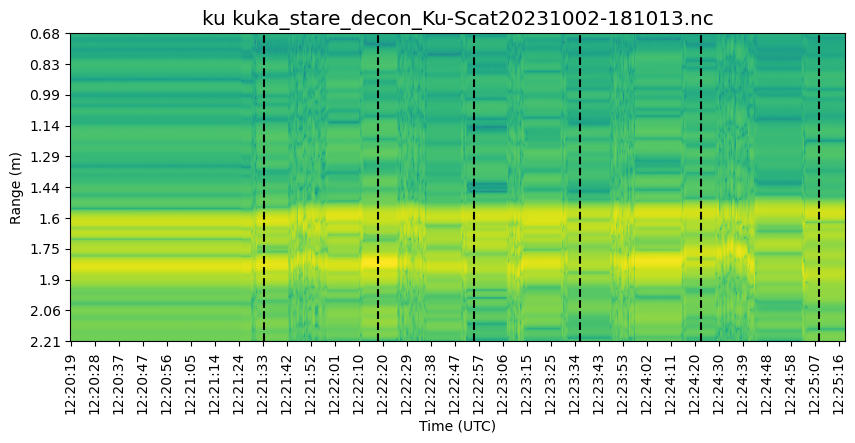

In [10]:
fa = 'kuka_stare_decon_Ka-Scat20231002-181204.nc'

fu = 'kuka_stare_decon_Ku-Scat20231002-181013.nc'

time_addition = datetime.timedelta(seconds=8)

ka_times = [(21,7),(21,55),(22,32),(23,10),(23,54),(24,47)] #Change last from (24,51) to (24,47)
vlines = [datetime.datetime(2023,10,2,12,a,b)+time_addition for (a,b) in ka_times]
            # ,(25,25)

ka_inds = kt.plot_file(fa,'ka',time_offset_s=-local_delta.seconds,vlines = vlines,directory=directory)

ku_times = [(21,26),(22,10),(22,47),(23,28),(24,15),(25,1)]
vlines = [datetime.datetime(2023,10,2,12,a,b)+time_addition for (a,b) in ku_times]
# ,(25,42)

ku_inds = kt.plot_file(fu,'ku',time_offset_s=-local_delta.seconds+115,vlines=vlines,directory=directory)

pit_numbers = [1,2,3,4,5,6]


ku_files = [fu]*len(pit_numbers)
ka_files = [fa]*len(pit_numbers)


for pitno, ka_ind, ku_ind, ka_file, ku_file in zip(pit_numbers,ka_inds,ku_inds,ka_files,ku_files):

    pits[pitno] = {}
    pits[pitno]['ka'] = ka_ind
    pits[pitno]['ku'] = ku_ind
    pits[pitno]['ka_file'] = ka_file
    pits[pitno]['ku_file'] = ku_file

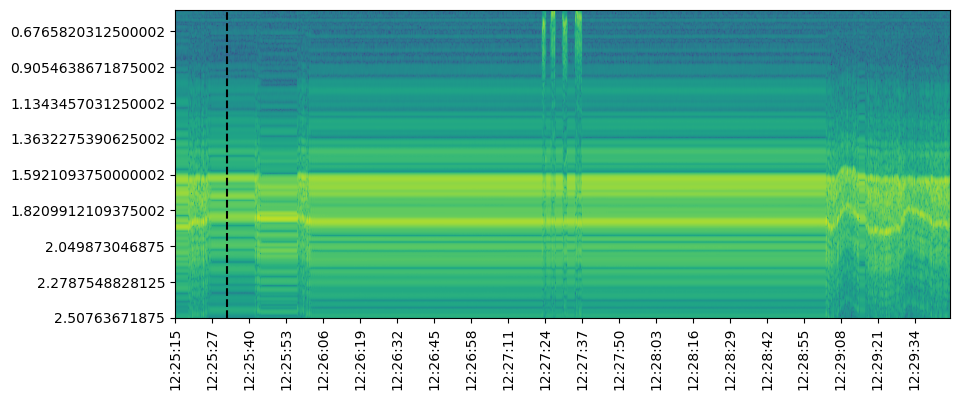

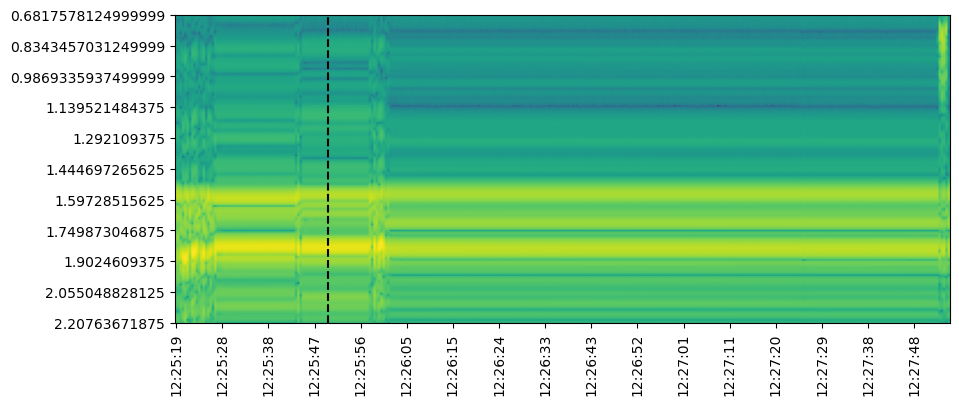

In [10]:
fa = 'kuka_stare_decon_Ka-Scat20231002-181704.nc'

fu = 'kuka_stare_decon_Ku-Scat20231002-181513.nc'

time_addition = datetime.timedelta(seconds=8)

ka_times = [(25,25)]
vlines = [datetime.datetime(2023,10,2,12,a,b)+time_addition for (a,b) in ka_times]

ka_inds = kt.plot_file(fa,'ka',time_offset_s=-local_delta.seconds,vlines = vlines,directory=directory)

ku_times = [(25,42)]
vlines = [datetime.datetime(2023,10,2,12,a,b)+time_addition for (a,b) in ku_times]

ku_inds = kt.plot_file(fu,'ku',time_offset_s=-local_delta.seconds+115,vlines=vlines,directory=directory)

pit_numbers = [7]


ku_files = [fu]*len(pit_numbers)
ka_files = [fa]*len(pit_numbers)


for pitno, ka_ind, ku_ind, ka_file, ku_file in zip(pit_numbers,ka_inds,ku_inds,ka_files,ku_files):

    pits[pitno] = {}
    pits[pitno]['ka'] = ka_ind
    pits[pitno]['ku'] = ku_ind
    pits[pitno]['ka_file'] = ka_file
    pits[pitno]['ku_file'] = ku_file

In [ ]:
pols = ['hh','vv',
        # 'hv','vh',
       ]

for pitno, data_dict in pits.items():

    y,m,day = kt.get_ymd_from_filename(pits[pitno]['ku_file'])
    
    for freq in ['ka','ku']:

        with Dataset(f'{directory}/{data_dict[f"{freq}_file"]}') as d:
            
            ranges = np.array(d['range'])

            start_ind = pits[pitno][freq]
            end_ind = start_ind+5

            for pol in pols:
            
                pits[pitno][f'{freq}_{pol}'] = np.mean(np.array(d[f'{pol}_power_decon0'])[:,start_ind:start_ind+5],axis=1)
                pits[pitno][f'{freq}_range'] = ranges

In [11]:
pols = ['hh','vv','hv','vh']

for pitno, data_dict in pits.items():

    y,m,day = kt.get_ymd_from_filename(pits[pitno]['ku_file'])
    
    for freq in ['ka','ku']:

        with Dataset(f'{directory}/{data_dict[f"{freq}_file"]}') as d:
            
            ranges = np.array(d['range'])

            start_ind = pits[pitno][freq]
            end_ind = start_ind+5

            for pol in pols:
            
                pits[pitno][f'{freq}_{pol}'] = np.mean(np.array(d[f'{pol}_power_decon0'])[:,start_ind:start_ind+5],axis=1)
                pits[pitno][f'{freq}_range'] = ranges

In [12]:
for freq in ['ka','ku']:

    for h in pits.keys():
    
        data = pits[h]
    
        dic = {pol:data[f'{freq}_{pol}'] for pol in pols}
        
        wvfms = pd.DataFrame(dic)
    
        wvfms.to_csv(f'../data/waveforms/Hangar_2023102_{h}_{freq}.csv')